# [Chapter 14: Eigenvalues and Eigenvectors - Deep Dive](https://youtu.be/PFDu9oVAE-g?si=j_fxjXk0fqKEXjMT)

## The Fundamental Concept

**Eigenvalues** and **eigenvectors** are among the most powerful concepts in linear algebra!

### The Core Equation

$$
A\vec{v} = \lambda \vec{v}
$$

- **Eigenvector** v: Direction that doesn't rotate under transformation A
- **Eigenvalue** λ: How much v gets scaled

### Why They Matter

- **Data Science**: Principal Component Analysis (PCA)
- **Physics**: Quantum mechanics, vibrations, stability analysis
- **Web**: Google's PageRank algorithm
- **Graphics**: Understanding transformations
- **ML**: Dimensionality reduction, spectral clustering

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)
np.set_printoptions(precision=3, suppress=True)

## 1. Geometric Intuition

Let's visualize what eigenvectors mean geometrically.

### Example: Horizontal Shear

$$
A = \begin{bmatrix} 1 & 1 \\\\ 0 & 1 \end{bmatrix}
$$

**Question**: Which vectors stay on their span after this transformation?

**Answer**: Vertical vectors! These are eigenvectors with eigenvalue λ = 1

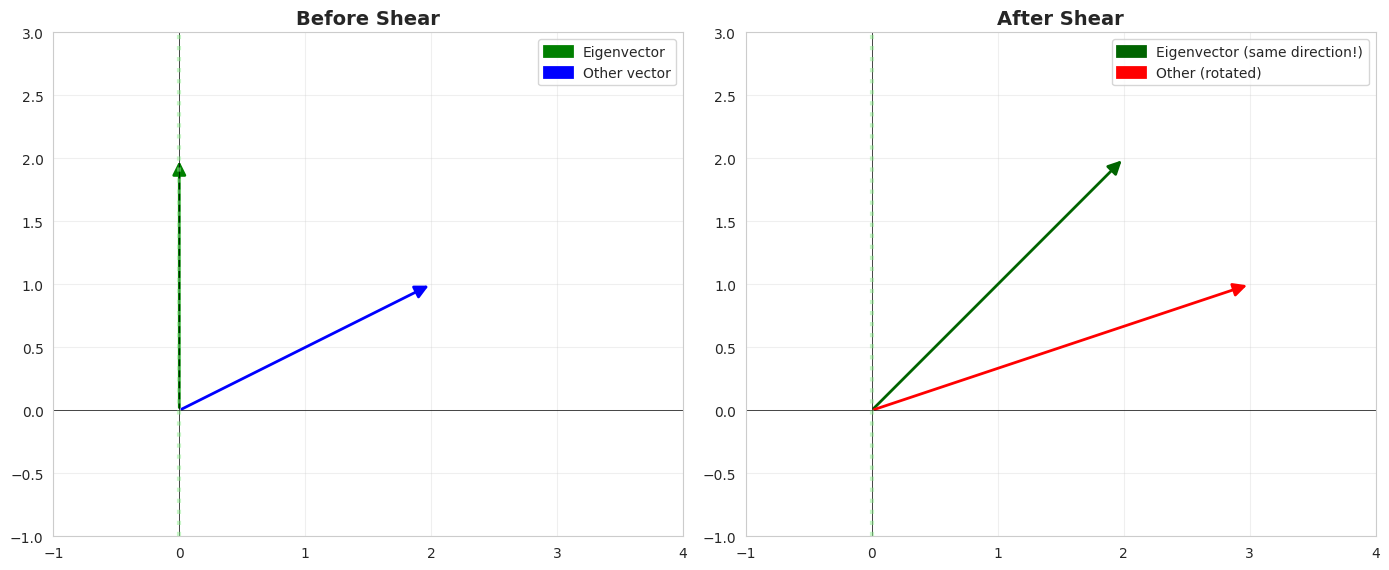

Shear matrix:
[[1 1]
 [0 1]]

Eigenvector before: [0 2]
Eigenvector after: [2 2]
Eigenvalue λ = 1.0

Non-eigenvector before: [2 1]
Non-eigenvector after: [3 1] (direction changed!)


In [24]:
def draw_vector_2d(ax, origin, vector, color='blue', label=None, width=0.01):
    """Draw a 2D vector."""
    from matplotlib.patches import FancyArrowPatch
    arrow = FancyArrowPatch(origin, origin + vector,
                           mutation_scale=20, lw=2, arrowstyle='-|>',
                           color=color, label=label)
    ax.add_patch(arrow)

def visualize_shear_eigenvectors():
    """Show eigenvectors for shear transformation."""
    A = np.array([[1, 1], [0, 1]])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Before
    ax1 = axes[0]
    ax1.set_xlim(-1, 4)
    ax1.set_ylim(-1, 3)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(0, color='k', linewidth=0.5)
    ax1.axvline(0, color='k', linewidth=0.5)
    
    v_eigen = np.array([0, 2])
    draw_vector_2d(ax1, np.zeros(2), v_eigen, 'green', 'Eigenvector', 0.012)
    ax1.axvline(0, color='lightgreen', linestyle=':', linewidth=3, alpha=0.5)
    
    v_other = np.array([2, 1])
    draw_vector_2d(ax1, np.zeros(2), v_other, 'blue', 'Other vector')
    
    ax1.set_title('Before Shear', fontsize=14, fontweight='bold')
    ax1.legend()
    
    # After
    ax2 = axes[1]
    ax2.set_xlim(-1, 4)
    ax2.set_ylim(-1, 3)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='k', linewidth=0.5)
    ax2.axvline(0, color='k', linewidth=0.5)
    
    Av_eigen = A @ v_eigen
    draw_vector_2d(ax2, np.zeros(2), Av_eigen, 'darkgreen', 'Eigenvector (same direction!)', 0.012)
    ax2.axvline(0, color='lightgreen', linestyle=':', linewidth=3, alpha=0.5)
    
    Av_other = A @ v_other
    draw_vector_2d(ax2, np.zeros(2), Av_other, 'red', 'Other (rotated)')
    
    ax2.set_title('After Shear', fontsize=14, fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Shear matrix:\n{A}\n")
    print(f"Eigenvector before: {v_eigen}")
    print(f"Eigenvector after: {Av_eigen}")
    print(f"Eigenvalue λ = {Av_eigen[1]/v_eigen[1]:.1f}\n")
    print(f"Non-eigenvector before: {v_other}")
    print(f"Non-eigenvector after: {Av_other} (direction changed!)")

visualize_shear_eigenvectors()

## 2. The Characteristic Equation

To find eigenvalues, solve:

$$
\det(A - \lambda I) = 0
$$

**Why?** We need (A - λI) to be non-invertible.

For 2×2 matrices:

$$
A = \begin{bmatrix} a & b \\\\ c & d \end{bmatrix}
$$

$$
\lambda^2 - (a+d)\lambda + (ad-bc) = 0
$$

Use the quadratic formula to solve!

In [25]:
def solve_characteristic_equation():
    """Solve characteristic equation step by step."""
    A = np.array([[4, 2], [1, 3]])
    
    print("Solving Characteristic Equation\n")
    print(f"Matrix A =\n{A}\n")
    
    a, b, c, d = A[0,0], A[0,1], A[1,0], A[1,1]
    
    print("Step 1: Form A - λI")
    print(f"  [{a}-λ  {b}  ]")
    print(f"  [{c}    {d}-λ]\n")
    
    print("Step 2: Compute determinant")
    print(f"  det = ({a}-λ)({d}-λ) - {b}·{c}")
    print(f"      = λ² - {a+d}λ + {a*d-b*c}\n")
    
    trace = a + d
    det = a*d - b*c
    disc = trace**2 - 4*det
    
    lambda1 = (trace + np.sqrt(disc)) / 2
    lambda2 = (trace - np.sqrt(disc)) / 2
    
    print(f"Step 3: Solve λ² - {trace}λ + {det} = 0")
    print(f"  λ = ({trace} ± √{disc}) / 2")
    print(f"  λ₁ = {lambda1:.3f}")
    print(f"  λ₂ = {lambda2:.3f}\n")
    
    eigenvalues_np = np.linalg.eigvals(A)
    print(f"NumPy verification: {eigenvalues_np}")

solve_characteristic_equation()

Solving Characteristic Equation

Matrix A =
[[4 2]
 [1 3]]

Step 1: Form A - λI
  [4-λ  2  ]
  [1    3-λ]

Step 2: Compute determinant
  det = (4-λ)(3-λ) - 2·1
      = λ² - 7λ + 10

Step 3: Solve λ² - 7λ + 10 = 0
  λ = (7 ± √9) / 2
  λ₁ = 5.000
  λ₂ = 2.000

NumPy verification: [5. 2.]


## Summary

### Key Insights

1. **Eigenvectors**: Special directions that only scale under transformation
2. **Eigenvalues**: The scaling factors
3. **Characteristic equation**: det(A - λI) = 0
4. **Properties**: Σλᵢ = tr(A), ∏λᵢ = det(A)

### Why They Matter

Eigenvectors reveal the "natural axes" of a transformation.
Understanding them is key to:
- Diagonalization
- Matrix powers
- Differential equations
- And much more!

---

**Next**: Quick tricks for computing eigenvalues!